In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from src.config import get_path, get_sample_window

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_P1 = get_path('data_phase1')
RES_P1 = get_path('results_phase1')

FIG_DIR = RES_P1 / 'figures'
TAB_DIR = RES_P1 / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

Z_macro = pd.read_parquet(DATA_P1 / 'Z_macro.parquet')
Z_crypto = pd.read_parquet(DATA_P1 / 'Z_crypto.parquet')
Z_full = pd.read_parquet(DATA_P1 / 'Z_full.parquet')

for name, df in [('Z_macro', Z_macro), ('Z_crypto', Z_crypto), ('Z_full', Z_full)]:
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} cols, dates {df["date"].min().date()} to {df["date"].max().date()}')

Z_macro: 772 rows, 9 cols, dates 2020-01-13 to 2023-08-31
Z_crypto: 772 rows, 7 cols, dates 2020-01-13 to 2023-08-31
Z_full: 772 rows, 15 cols, dates 2020-01-13 to 2023-08-31


#### 1. Macro Vector Time Series (Z_macro, standardized)

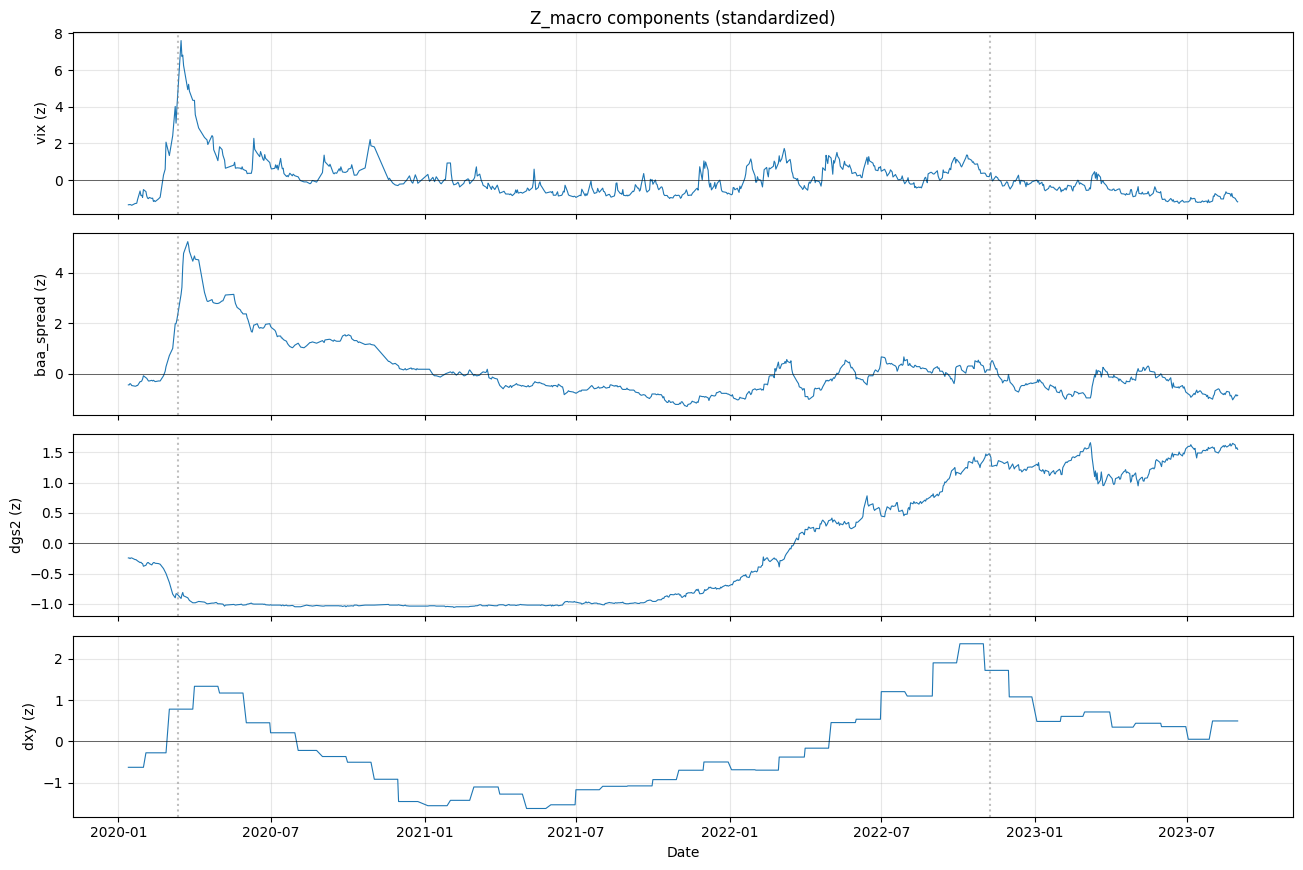

In [3]:
macro_cols = ['vix', 'baa_spread', 'dgs2', 'dxy']

fig, axes = plt.subplots(len(macro_cols), 1, figsize=(13, 2.2 * len(macro_cols)), sharex=True)
for ax, col in zip(axes, macro_cols):
    ax.plot(Z_macro['date'], Z_macro[col], linewidth=0.8, color='C0')
    ax.axhline(0, color='black', linewidth=0.4)
    ax.set_ylabel(f'{col} (z)')
    ax.axvline(pd.Timestamp('2020-03-12'), color='gray', linestyle=':', alpha=0.5)
    ax.axvline(pd.Timestamp('2022-11-08'), color='gray', linestyle=':', alpha=0.5)

axes[0].set_title('Z_macro components (standardized)')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_z_macro_timeseries.png', dpi=150)
plt.show()

#### 2. Crypto Vector Time Series (Z_crypto, standardized)

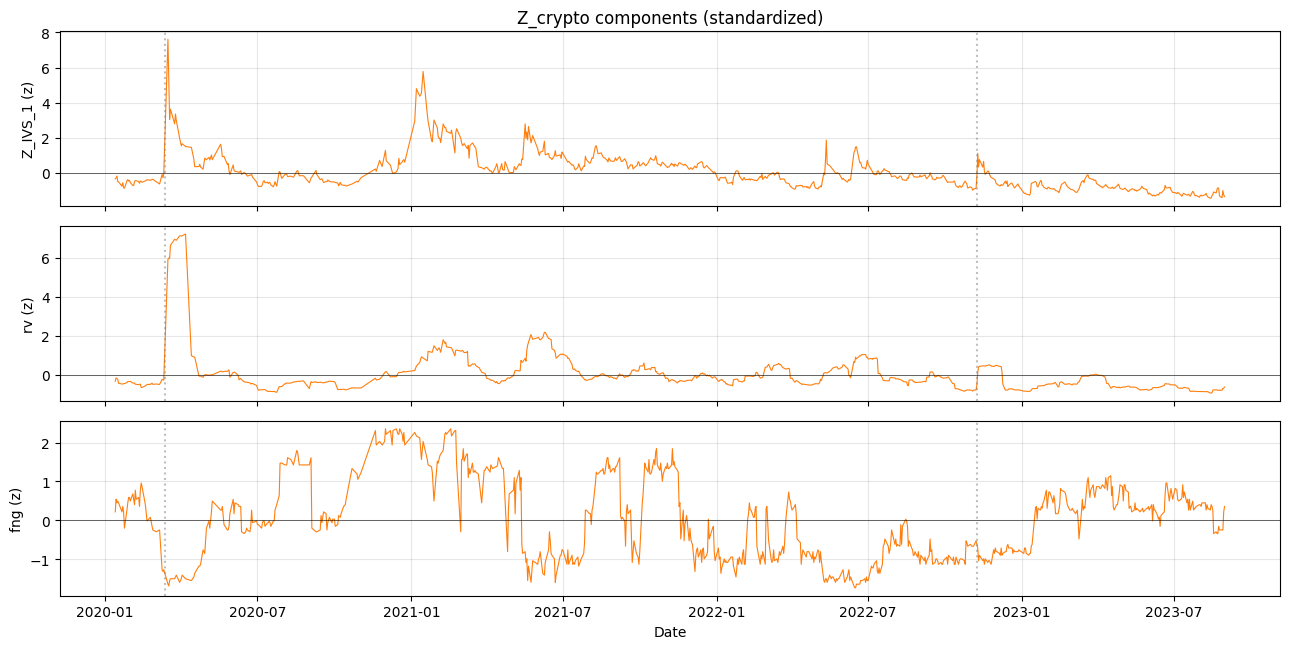

In [4]:
crypto_cols = ['Z_IVS_1', 'rv', 'fng']

fig, axes = plt.subplots(len(crypto_cols), 1, figsize=(13, 2.2 * len(crypto_cols)), sharex=True)
for ax, col in zip(axes, crypto_cols):
    ax.plot(Z_crypto['date'], Z_crypto[col], linewidth=0.8, color='C1')
    ax.axhline(0, color='black', linewidth=0.4)
    ax.set_ylabel(f'{col} (z)')
    ax.axvline(pd.Timestamp('2020-03-12'), color='gray', linestyle=':', alpha=0.5)
    ax.axvline(pd.Timestamp('2022-11-08'), color='gray', linestyle=':', alpha=0.5)

axes[0].set_title('Z_crypto components (standardized)')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_z_crypto_timeseries.png', dpi=150)
plt.show()

#### 3. Correlation Heatmap (Z_full)

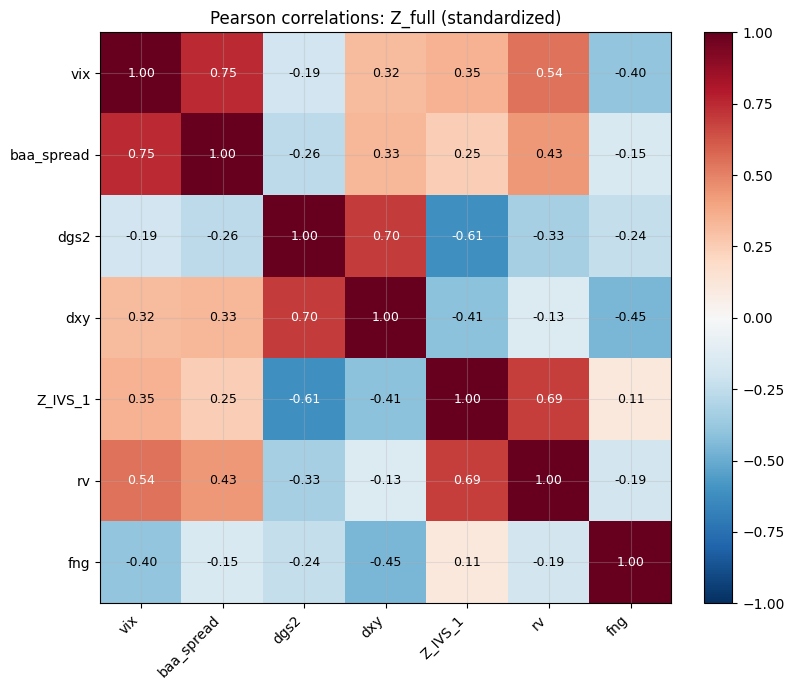

In [5]:
all_cols = macro_cols + crypto_cols
corr = Z_full[all_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(all_cols)))
ax.set_yticks(range(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_yticklabels(all_cols)
for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black', fontsize=9)
ax.set_title('Pearson correlations: Z_full (standardized)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_conditioning_correlations.png', dpi=150)
plt.show()

#### 4. Coverage Report

In [6]:
coverage = pd.read_csv(RES_P1 / 'conditioning_coverage.csv')
print(coverage.to_string(index=False))

specification            variable  n_obs  n_non_null  coverage_pct first_valid last_valid
      Z_macro                 vix    772         772        100.00  2020-01-13 2023-08-31
      Z_macro          baa_spread    772         772        100.00  2020-01-13 2023-08-31
      Z_macro                dgs2    772         772        100.00  2020-01-13 2023-08-31
      Z_macro                 dxy    772         772        100.00  2020-01-13 2023-08-31
      Z_macro ALL (complete case)    772         772        100.00  2020-01-13 2023-08-31
     Z_crypto             Z_IVS_1    772         772        100.00  2020-01-13 2023-08-31
     Z_crypto                  rv    772         772        100.00  2020-01-13 2023-08-31
     Z_crypto                 fng    772         772        100.00  2020-01-13 2023-08-31
     Z_crypto ALL (complete case)    772         772        100.00  2020-01-13 2023-08-31
       Z_full                 vix    772         772        100.00  2020-01-13 2023-08-31
       Z_f

#### 5. Volatility Terciles Diagnostic

For Phase 3, the conditional kernel will be estimated within tercile-based regimes
of an aggregate volatility measure. Check that the proposed conditioning variables
induce coherent regimes that align with stress events.

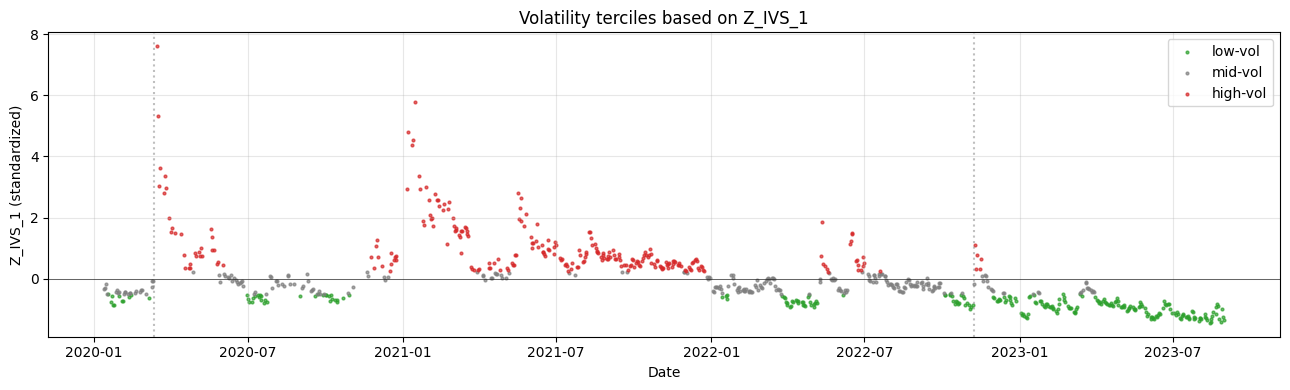


Tercile breakpoints (Z_IVS_1):
              min       max  count
tercile                           
low     -1.448847 -0.509043    258
mid     -0.507245  0.225262    257
high     0.228563  7.610258    257


In [7]:
z = Z_crypto[['date', 'Z_IVS_1']].dropna()
z['tercile'] = pd.qcut(z['Z_IVS_1'], q=3, labels=['low', 'mid', 'high'])

fig, ax = plt.subplots(figsize=(13, 4))
for label, color in zip(['low', 'mid', 'high'], ['C2', 'C7', 'C3']):
    sub = z[z['tercile'] == label]
    ax.scatter(sub['date'], sub['Z_IVS_1'], s=4, label=f'{label}-vol', color=color, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.4)
ax.axvline(pd.Timestamp('2020-03-12'), color='gray', linestyle=':', alpha=0.5)
ax.axvline(pd.Timestamp('2022-11-08'), color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Z_IVS_1 (standardized)')
ax.set_xlabel('Date')
ax.set_title('Volatility terciles based on Z_IVS_1')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_volatility_terciles.png', dpi=150)
plt.show()

print(f'\nTercile breakpoints (Z_IVS_1):')
print(z.groupby('tercile')['Z_IVS_1'].agg(['min', 'max', 'count']))